In [40]:
import pandas as pd
import numpy as np
df=pd.read_csv('advertising.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [41]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [42]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [43]:
x=df.drop(columns=['Sales'])
x.ndim

2

In [44]:
y=df['Sales']
y.ndim

1

<Axes: xlabel='TV', ylabel='Sales'>

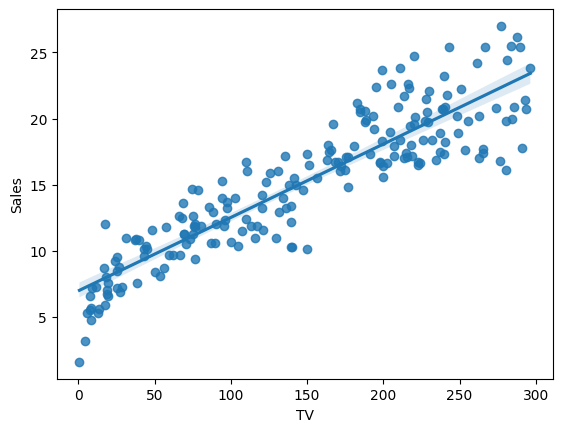

In [45]:
import seaborn as sns
sns.regplot(x=df['TV'],y=y)

<Axes: xlabel='Radio', ylabel='Sales'>

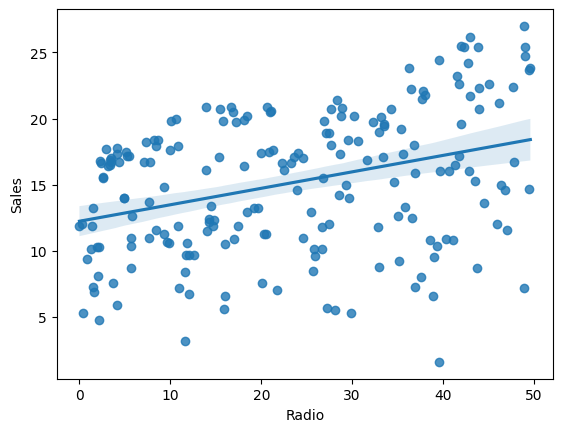

In [46]:
sns.regplot(x=df['Radio'],y=y)

<Axes: xlabel='Newspaper', ylabel='Sales'>

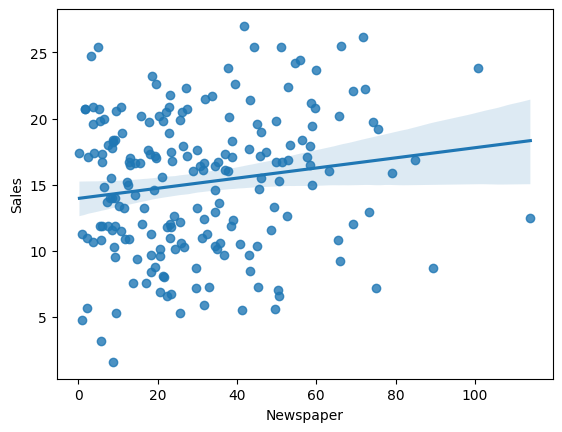

In [47]:
sns.regplot(x=df['Newspaper'],y=y)

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
from sklearn.linear_model import LinearRegression
linear=LinearRegression()
linear.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred = linear.predict(x_test)
y_pred


array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [51]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error,r2_score,mean_absolute_percentage_error
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
mape=mean_absolute_percentage_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print('MAPE:',mape)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAPE: 0.10880888971170635
MAE: 1.2748262109549338
MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R2: 0.9059011844150826


In [52]:
coeff_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': linear.coef_
})

print(coeff_df)
print("Intercept:", linear.intercept_)


     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337
Intercept: 4.714126402214127
